# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `Pillow (PIL)` library. Complete both tasks and save your output images for comparison.


In [13]:
# Import the library
from PIL import Image
import matplotlib.pyplot as plt

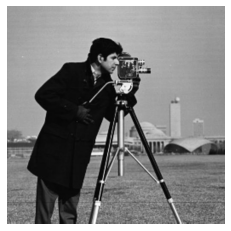

In [27]:
# ── Load image ────────────────────────────────────
image = Image.open("cameraman.jpg").convert("RGB")

# Show image correctly in Jupyter
plt.imshow(image,cmap='gray')
plt.axis("off")
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [31]:
# Get the size of the image
width, height = image.size
# scaling factors
scale_x = 2
scale_y = 2

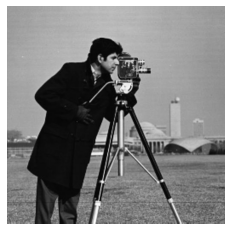

In [33]:
# ── 1. Increase size (scale ×2)
scaled_image = image.resize((width * scale_x, height * scale_y), Image.LANCZOS)

# Show result
plt.imshow(scaled_image, cmap='gray')
plt.axis("off")
plt.show()


In [35]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")

scaled_image.save("task1_1_scaled.jpg")

print("Original size:", image.size)
print("Scaled size:", scaled_image.size)


Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [36]:
cx = 2
cy = 1

# Resize image
stretched_image = image.resize((width * cx, height * cy), Image.LANCZOS)


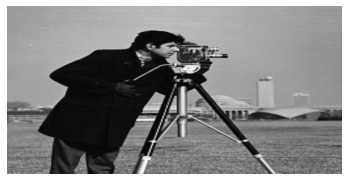

In [39]:
# Show result
plt.imshow(stretched_image, cmap='gray')
plt.axis("off")
plt.show()

In [40]:
# Save image
stretched_image.save("task1_1_stretched.jpg")
# Print sizes
print("Original size:", image.size)
print("Stretched size:", stretched_image.size)

Original size: (512, 512)
Stretched size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

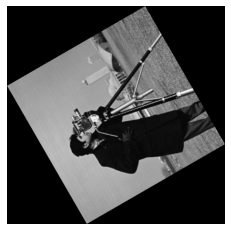

Original size: (512, 512)
Rotated size: (700, 700)


In [42]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_image = image.rotate(120, expand=True)

plt.imshow(rotated_image, cmap='gray')
plt.axis("off")
plt.show()

rotated_image.save("task1_2_rotated.jpg")

print("Original size:", image.size)
print("Rotated size:", rotated_image.size)

### 3. Shear

In [43]:
# -- c. Get the image dimensions ────────────────────
width, height = image.size

In [45]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.

shear_factor = 0.5

shear_matrix = (1, shear_factor, 0, 0, 1, 0)

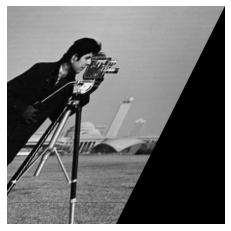

In [46]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_image = image.transform(
    (width, height),
    Image.AFFINE,
    shear_matrix
)

plt.imshow(sheared_image, cmap='gray')
plt.axis("off")
plt.show()

In [47]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_image.save("task1_3_sheared.jpg")

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

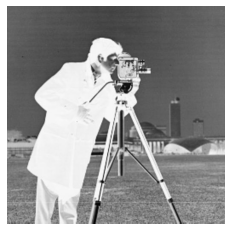

In [48]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation

import numpy as np
from PIL import Image

img_array = np.array(image)

negative_image = 255 - img_array

negative_image = Image.fromarray(negative_image)

plt.imshow(negative_image, cmap='gray')
plt.axis("off")
plt.show()



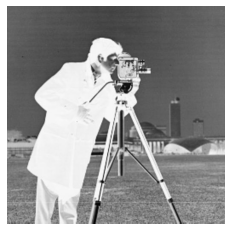

In [49]:
# Method 2: PIL's ImageOps
from PIL import ImageOps

negative_image_2 = ImageOps.invert(image.convert("RGB"))

plt.imshow(negative_image_2, cmap='gray')
plt.axis("off")
plt.show()

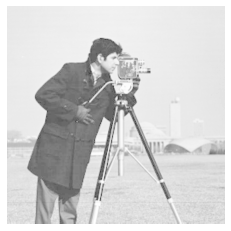

In [50]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

import numpy as np

img_array = np.array(image.convert("L"), dtype=np.float32)

c = 255 / np.log(1 + 255)


# Apply the log transformation to each pixel
log_image = c * np.log(1 + img_array)

log_image = np.array(log_image, dtype=np.uint8)

plt.imshow(log_image, cmap='gray')
plt.axis("off")
plt.show()

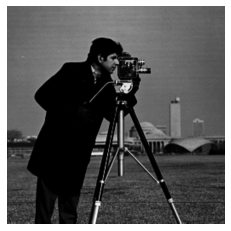

In [52]:

# ── 3. Power-law / Gamma correction ───────────────
# Convert image to grayscale array
img_array = np.array(image.convert("L"), dtype=np.float32)

# Normalize to range [0,1]
normalized = img_array / 255.0

gamma = 2.0
gamma_corrected = np.power(normalized, gamma)

# Convert back to [0,255]
gamma_image = np.uint8(gamma_corrected * 255)

plt.imshow(gamma_image, cmap='gray')
plt.axis("off")
plt.show()